## **A/B Testing** 
## **Homework 2**

The first step is to create the Bandit class and set up the environment. Packages like NumPy, Pandas, Matplotlib, and abc are imported to handle numbers, data, plotting, and abstract classes. The Bandit class is made as an abstract base class with four methods: pull(), update(), experiment(), and report(). Each method is left empty so that any algorithm that uses this class must define them. The class also keeps the true rewards for each arm, which shows the real performance of each advertisement. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from abc import ABC, abstractmethod
import logging

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger(__name__)

BANDIT_REWARDS = [1, 2, 3, 4]
NUM_TRIALS = 20000

In [2]:
class Bandit(ABC):
    
    def __init__(self, true_mean):
        self.true_mean = true_mean  # the real reward value of this ad

    @abstractmethod
    def pull(self):
        pass

    @abstractmethod
    def update(self, reward):
        pass

    @abstractmethod
    def experiment(self):
        pass

    @abstractmethod
    def report(self):
        pass

The next step is to implement the Epsilon-Greedy algorithm as a subclass of the Bandit class. For each arm, an estimated mean reward and the number of times it has been selected are stored. When an arm is pulled, a reward is generated using a normal distribution around its true mean to simulate randomness. After receiving the reward, the estimated mean is updated using an incremental formula, so there is no need to store all past rewards. During the experiment, the algorithm chooses an arm using a simple rule: with probability 
1/t, it selects a random arm (exploration), and otherwise it selects the arm with the highest estimated reward (exploitation). This approach allows the algorithm to explore more at the beginning and gradually focus on the best-performing arm as it learns over time.

In [3]:
class EpsilonGreedy(Bandit):

    def __init__(self, true_mean):
        super().__init__(true_mean)  
        self.estimated_mean = 0.0    
        self.n_pulls = 0             

    def pull(self):
        return np.random.randn() + self.true_mean

    def update(self, reward):
        self.n_pulls += 1
        self.estimated_mean += (reward - self.estimated_mean) / self.n_pulls

    def experiment(self):
        pass  

    def report(self):
        logger.info(
            f"EpsilonGreedy | true_mean={self.true_mean} | "
            f"estimated={self.estimated_mean:.4f} | pulls={self.n_pulls}"
        )

The next step is to implement the Thompson Sampling algorithm as another subclass of the Bandit class. For each arm, a belief about its true reward is maintained using a mean and a precision (which represents confidence). At each step, a random sample is drawn from this belief for every arm, and the arm with the highest sampled value is selected. After receiving the reward, the belief is updated using a formula that combines the previous estimate with the new observation. This method naturally balances exploration and exploitation, because arms with more uncertainty are more likely to be selected. Over time, as more data is collected, the estimates become more accurate and the algorithm focuses more on the best arm.

In [4]:
class ThompsonSampling(Bandit):
    def __init__(self, true_mean, precision=1.0):
        super().__init__(true_mean)
        self.precision = precision        
        self._posterior_mean = 0.0
        self._posterior_lambda = 1.0     
        self.n_pulls = 0

    def pull(self):
        return np.random.randn() / np.sqrt(self.precision) + self.true_mean

    def update(self, reward):
        new_lambda = self._posterior_lambda + self.precision
        new_mean = (
            self._posterior_lambda * self._posterior_mean
            + self.precision * reward
        ) / new_lambda
        self._posterior_lambda = new_lambda
        self._posterior_mean = new_mean
        self.n_pulls += 1

    def sample(self):
        return np.random.randn() / np.sqrt(self._posterior_lambda) \
               + self._posterior_mean

    def experiment(self):
        pass

    def report(self):
        logger.info(
            f"ThompsonSampling | true_mean={self.true_mean} | "
            f"posterior_mean={self._posterior_mean:.4f} | pulls={self.n_pulls}"
        )

The next step is to run the experiments for both algorithms. Separate functions are used to simulate the process for Epsilon-Greedy and Thompson Sampling over 20,000 trials. In each trial, an arm is selected based on the algorithm’s rule, a reward is generated, and the corresponding arm is updated. The reward from each trial is stored, along with the cumulative reward over time. In addition, the estimated mean for each arm is tracked at every step to observe how the algorithm learns. All results are also prepared in a structured format so they can later be saved to a CSV file. This step is important because it simulates how the algorithms perform in practice and collects all the data needed for comparison and analysis.

In [5]:
def run_epsilon_greedy():
    arms = [EpsilonGreedy(m) for m in BANDIT_REWARDS]
    rewards, cumulative, csv_rows, histories = [], [], [], [[] for _ in arms]
    total = 0.0

    for t in range(1, NUM_TRIALS + 1):
        eps = 1.0 / t  
        if np.random.random() < eps:
            chosen = np.random.randint(len(arms))
        else:
            chosen = int(np.argmax([a.estimated_mean for a in arms]))

        reward = arms[chosen].pull()
        arms[chosen].update(reward)
        total += reward
        rewards.append(reward)
        cumulative.append(total)
        csv_rows.append({"Bandit": chosen+1, "Reward": reward, "Algorithm": "EpsilonGreedy"})

        for i, arm in enumerate(arms):
            histories[i].append(arm.estimated_mean)

    for arm in arms:
        arm.report()

    return rewards, cumulative, csv_rows, histories


def run_thompson():
    arms = [ThompsonSampling(m) for m in BANDIT_REWARDS]
    rewards, cumulative, csv_rows, histories = [], [], [], [[] for _ in arms]
    total = 0.0

    for _ in range(NUM_TRIALS):
        chosen = int(np.argmax([a.sample() for a in arms]))

        reward = arms[chosen].pull()
        arms[chosen].update(reward)
        total += reward
        rewards.append(reward)
        cumulative.append(total)
        csv_rows.append({"Bandit": chosen+1, "Reward": reward, "Algorithm": "ThompsonSampling"})

        for i, arm in enumerate(arms):
            histories[i].append(arm._posterior_mean)

    for arm in arms:
        arm.report()

    return rewards, cumulative, csv_rows, histories

The next step is to visualize the results using plots. One function is used to show how the estimated mean reward of each arm changes over time, which helps to see how the algorithm learns which arm is best. Another plot is used to compare the cumulative rewards of Epsilon-Greedy and Thompson Sampling. 

In [6]:
def plot1(histories, title):
    """Plot how each arm's estimated mean changed over time."""
    plt.figure(figsize=(12, 5))
    for i, h in enumerate(histories):
        plt.plot(h, label=f"Arm {i+1} (true μ={BANDIT_REWARDS[i]})", alpha=0.85)
    plt.xlabel("Trial")
    plt.ylabel("Estimated Mean Reward")
    plt.title(f"{title} — Learning Process")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

def plot2(eg_cum, ts_cum):
    """Compare cumulative rewards of both algorithms."""
    plt.figure(figsize=(12, 5))
    plt.plot(eg_cum, label="Epsilon-Greedy", color="#E07B54")
    plt.plot(ts_cum, label="Thompson Sampling", color="#5B8DB8")
    plt.xlabel("Trial")
    plt.ylabel("Cumulative Reward")
    plt.title("Cumulative Rewards: Epsilon-Greedy vs Thompson Sampling")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

def report(eg_cum, ts_cum):
    optimal = max(BANDIT_REWARDS)
    print("\n" + "="*50)
    print(f"{'Algorithm':<22} {'Cum. Reward':>12} {'Cum. Regret':>12}")
    print("-"*50)
    print(f"{'Epsilon-Greedy':<22} {eg_cum[-1]:>12.2f} {optimal*NUM_TRIALS - eg_cum[-1]:>12.2f}")
    print(f"{'Thompson Sampling':<22} {ts_cum[-1]:>12.2f} {optimal*NUM_TRIALS - ts_cum[-1]:>12.2f}")
    print("="*50)

INFO: EpsilonGreedy | true_mean=1 | estimated=0.7262 | pulls=4
INFO: EpsilonGreedy | true_mean=2 | estimated=0.9423 | pulls=1
INFO: EpsilonGreedy | true_mean=3 | estimated=2.9811 | pulls=121
INFO: EpsilonGreedy | true_mean=4 | estimated=3.9937 | pulls=19874
INFO: ThompsonSampling | true_mean=1 | posterior_mean=0.1732 | pulls=2
INFO: ThompsonSampling | true_mean=2 | posterior_mean=0.6604 | pulls=1
INFO: ThompsonSampling | true_mean=3 | posterior_mean=2.9901 | pulls=590
INFO: ThompsonSampling | true_mean=4 | posterior_mean=3.9984 | pulls=19407


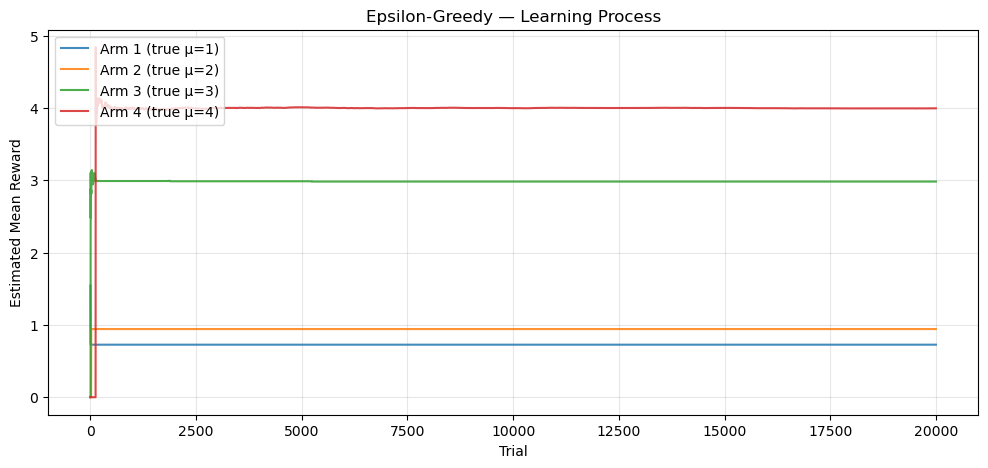

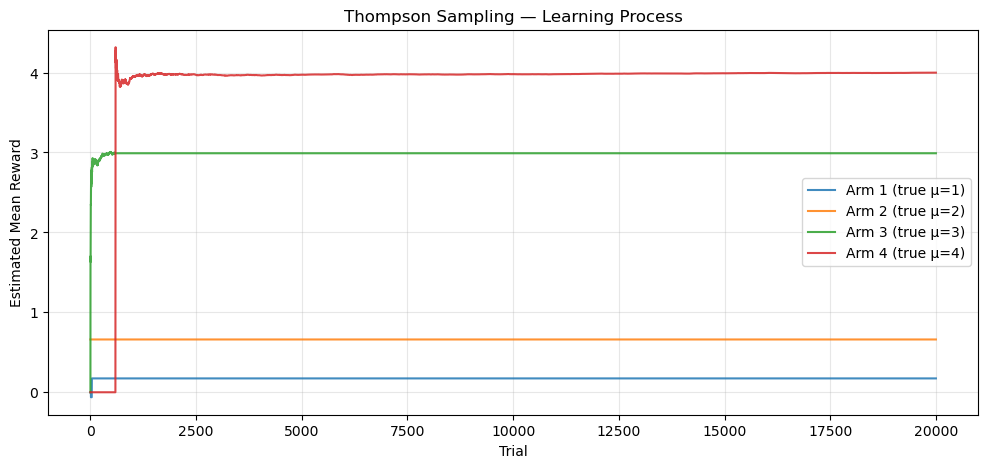

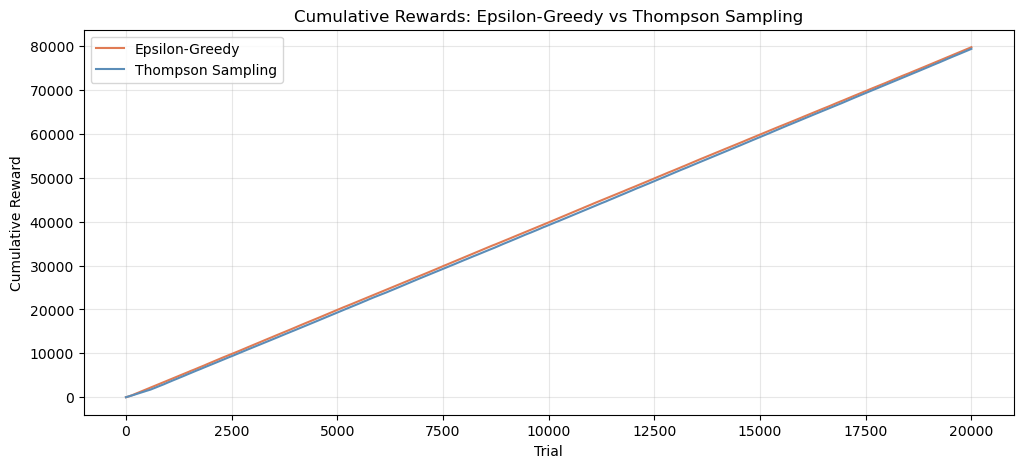

CSV saved!

Algorithm               Cum. Reward  Cum. Regret
--------------------------------------------------
Epsilon-Greedy             79734.47       265.53
Thompson Sampling          79369.13       630.87


In [7]:
np.random.seed(42)

eg_rewards, eg_cum, eg_rows, eg_hist = run_epsilon_greedy()
ts_rewards, ts_cum, ts_rows, ts_hist = run_thompson()

plot1(eg_hist, "Epsilon-Greedy")
plot1(ts_hist, "Thompson Sampling")

plot2(eg_cum, ts_cum)

df = pd.DataFrame(eg_rows + ts_rows)
df.to_csv("bandit_results.csv", index=False)
print("CSV saved!")

report(eg_cum, ts_cum)

Both algorithms were tested on 4 advertisement options with rewards of 1, 2, 3, and 4. Within the first few hundred trials, both correctly identified Ad 4 as the best option and started selecting it almost exclusively for the remaining 20,000 trials. As a result, both accumulated very similar total rewards — Epsilon-Greedy earned 79,734 and Thompson Sampling earned 79,369 out of a maximum possible 80,000 — meaning both wasted very little reward, with Epsilon-Greedy wasting only 265 and Thompson Sampling wasting 631. Epsilon-Greedy performed slightly better here because its epsilon decays very fast (1/t), which made it commit to the best ad quickly and stop exploring. Thompson Sampling took a little longer to fully commit because it continuously samples from its beliefs and never completely stops exploring — which costs slightly more in this experiment but makes it more adaptable in real-world situations where rewards can change over time.

### **Better Implementation Plan**


The current implementation is a good starting point, but it can be taken much further to reflect how advertising actually works in the real world. Right now the experiment assumes that each ad always gives the same reward throughout all 20,000 trial.  In reality, ad rewards are not stable — user behavior changes by time of day, day of week, and season, meaning an ad that performs best in the morning may perform worst at night. A better implementation would account for this by making the rewards change over time and testing whether the algorithms can adapt to these changes. Also, the experiment currently treats all four ads equally at the start, assuming we know nothing about them, but in real advertising we often already have some knowledge about which ads performed well in past campaigns. A smarter implementation would allow Thompson Sampling to start with this prior knowledge instead of assuming complete ignorance, which would reduce a lot of the mistakes that happen in the early trials. Finally, the current code measures success only by cumulative reward, but in real business settings the cost of showing an ad also matters — a slightly lower-reward ad that costs half as much to display might actually be the better business decision. Adding cost into the experiment would make this study far more applicable to real-world marketing and would show a much deeper understanding of what this type of problem is actually trying to solve.